# Iris Recognition 1:N — Pipeline Visualization

Đi hết pipeline nhận dạng mống mắt: **ảnh mắt → CLAHE → U-Net segment → Rubber Sheet normalize → ResNet50+ArcFace embedding → FAISS 1:N search**.

Mỗi section minh họa một bước bằng hình ảnh + số liệu thật.

In [1]:
import os, sys, json, random
from pathlib import Path
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
%matplotlib inline

# Về thư mục gốc project để mọi đường dẫn khớp với scripts/
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
sys.path.insert(0, "scripts")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
# Import các hàm pipeline có sẵn trong scripts/
from preprocess import apply_clahe
from normalize_iris import load_unet, predict_mask, extract_circles, rubber_sheet
from train_arcface import IrisEmbedder, EMBED_DIM
from build_gallery import TRANSFORM
import faiss

# Load 2 model đã train
unet = load_unet(Path("models/unet_best.pth"), "resnet34", device)
embedder = IrisEmbedder(embed_dim=EMBED_DIM)
embedder.load_state_dict(torch.load("models/arcface_best.pth", map_location=device))
embedder.eval().to(device)
print("Đã load U-Net + ArcFace embedder")

Đã load U-Net + ArcFace embedder


## 1. Tổng quan dataset

CASIA-Iris-Interval, chia subject-disjoint cho 2 giai đoạn (segmentation và recognition).

In [3]:
subjects = {p.parts[-3] for p in Path('datasets/preprocessed').rglob('*.jpg')}
def cnt(d, pat): return len(list(Path(d).rglob(pat)))
print(f"Tổng subject              : {len(subjects)}")
print(f"Ảnh preprocessed          : {cnt('datasets/preprocessed','*.jpg')}")
print(f"Mask label tay (U-Net)    : {cnt('datasets/segmentation_masks','*_mask.png')}")
print(f"Train (ArcFace)           : {cnt('datasets/train','*.png')} ảnh")
print(f"Gallery (đăng ký)         : {cnt('datasets/normalized_gallery','*.png')} ảnh")
print(f"Probe  (truy vấn)         : {cnt('datasets/normalized_probe','*.png')} ảnh")

Tổng subject              : 249
Ảnh preprocessed          : 2639
Mask label tay (U-Net)    : 101
Train (ArcFace)           : 2161 ảnh
Gallery (đăng ký)         : 141 ảnh
Probe  (truy vấn)         : 337 ảnh


## 2. Tiền xử lý — CLAHE

Grayscale + CLAHE (Contrast Limited Adaptive Histogram Equalization) làm rõ vân iris.

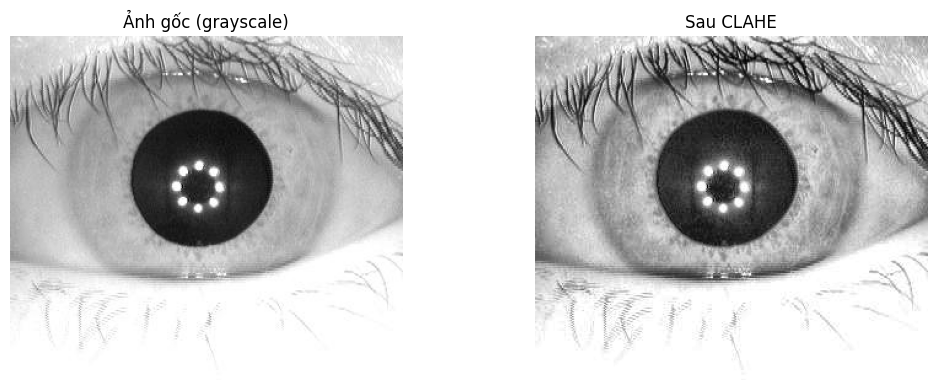

In [4]:
raw = sorted(Path('datasets/raw').rglob('*.jpg'))[0]
g0 = cv2.imread(str(raw), cv2.IMREAD_GRAYSCALE)
enh = apply_clahe(g0)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(g0, cmap='gray');  ax[0].set_title('Ảnh gốc (grayscale)'); ax[0].axis('off')
ax[1].imshow(enh, cmap='gray'); ax[1].set_title('Sau CLAHE');           ax[1].axis('off')
plt.tight_layout(); plt.show()

## 3. Segmentation — U-Net (ResNet34)

Phân vùng iris/pupil/background. Train bằng 100 mask label tay, Dice+CE loss.

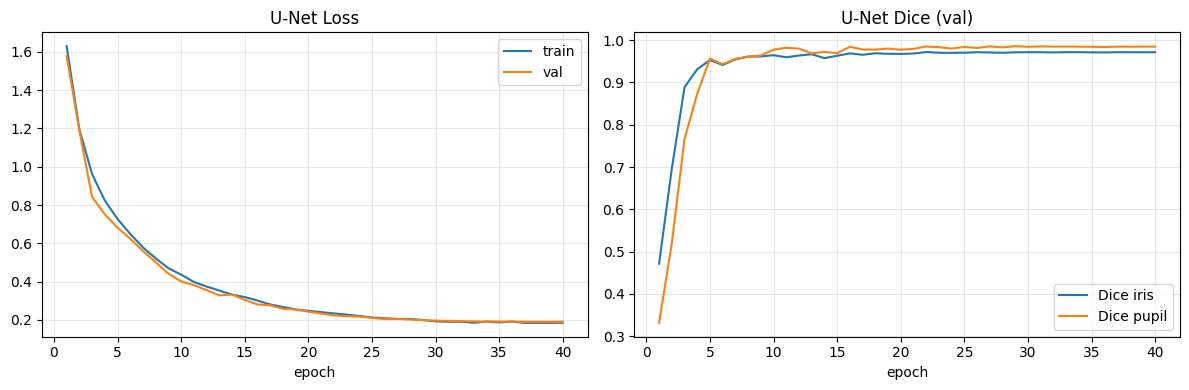

Best Dice — iris: 0.9716  pupil: 0.9855


In [5]:
h = json.load(open('models/unet_history.json'))
ep = [x['epoch'] for x in h]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ep, [x['train_loss'] for x in h], label='train')
ax[0].plot(ep, [x['val_loss']   for x in h], label='val')
ax[0].set_title('U-Net Loss'); ax[0].set_xlabel('epoch'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(ep, [x['dice_iris']  for x in h], label='Dice iris')
ax[1].plot(ep, [x['dice_pupil'] for x in h], label='Dice pupil')
ax[1].set_title('U-Net Dice (val)'); ax[1].set_xlabel('epoch'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print(f"Best Dice — iris: {max(x['dice_iris'] for x in h):.4f}  pupil: {max(x['dice_pupil'] for x in h):.4f}")

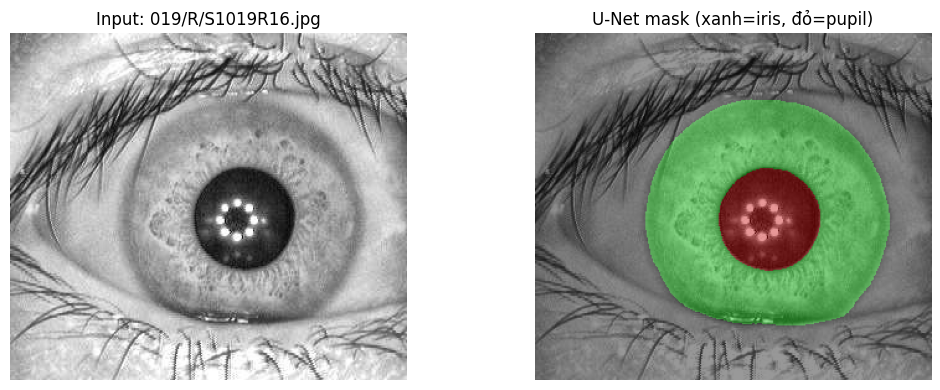

In [6]:
# Mask dự đoán trên subject CHƯA label (>=009) → kiểm tra tổng quát hóa
ip = sorted(p for p in Path('datasets/preprocessed').rglob('*.jpg') if int(p.parts[-3]) >= 9)[100]
g = cv2.imread(str(ip), cv2.IMREAD_GRAYSCALE)
m = predict_mask(unet, g, device)
ov = cv2.cvtColor(g, cv2.COLOR_GRAY2BGR); col = np.zeros_like(ov)
col[m == 1] = [0, 200, 0]; col[m == 2] = [200, 0, 0]
blend = cv2.addWeighted(ov, 0.6, col, 0.4, 0)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(g, cmap='gray'); ax[0].set_title('Input: ' + '/'.join(ip.parts[-3:])); ax[0].axis('off')
ax[1].imshow(blend);          ax[1].set_title('U-Net mask (xanh=iris, đỏ=pupil)');   ax[1].axis('off')
plt.tight_layout(); plt.show()

## 4. Chuẩn hóa — Rubber Sheet

"Duỗi" vành iris từ tọa độ cực → chữ nhật 64×512. Noise mask đánh dấu vùng mí/lông mi che.

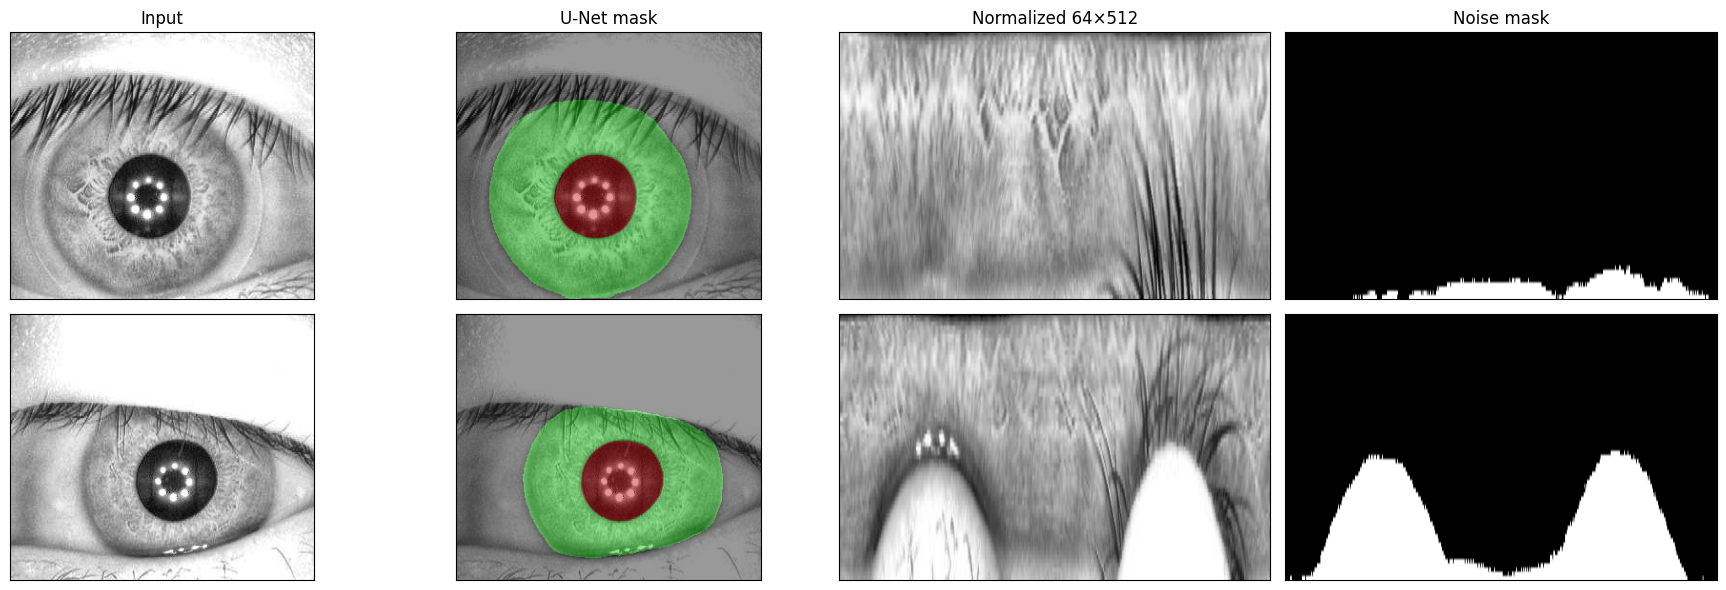

In [7]:
random.seed(3)
picks = random.sample([p for p in Path('datasets/preprocessed').rglob('*.jpg') if int(p.parts[-3]) >= 9], 2)
titles = ['Input', 'U-Net mask', 'Normalized 64×512', 'Noise mask']
fig, ax = plt.subplots(2, 4, figsize=(18, 6))
for r, ip in enumerate(picks):
    g = cv2.imread(str(ip), cv2.IMREAD_GRAYSCALE)
    m = predict_mask(unet, g, device); pu, ir = extract_circles(m)
    ov = cv2.cvtColor(g, cv2.COLOR_GRAY2BGR); col = np.zeros_like(ov)
    col[m == 1] = [0, 200, 0]; col[m == 2] = [200, 0, 0]
    bl = cv2.addWeighted(ov, 0.6, col, 0.4, 0)
    ax[r, 0].imshow(g, cmap='gray'); ax[r, 1].imshow(bl)
    if pu and ir:
        norm, noise = rubber_sheet(g, m, pu, ir)
        ax[r, 2].imshow(norm, cmap='gray', aspect='auto')
        ax[r, 3].imshow(noise, cmap='gray', aspect='auto')
    for c in range(4):
        ax[r, c].set_xticks([]); ax[r, c].set_yticks([])
        if r == 0: ax[r, c].set_title(titles[c])
plt.tight_layout(); plt.show()

## 5. Embedding — ResNet50 + ArcFace

Mỗi iris phẳng → vector 256-D. ArcFace ép cùng người gần nhau, khác người xa nhau.

> Lưu ý: đường cong dưới là từ một lần train đầy đủ 60 epoch (tham khảo); checkpoint đang dùng là bản val tốt nhất.

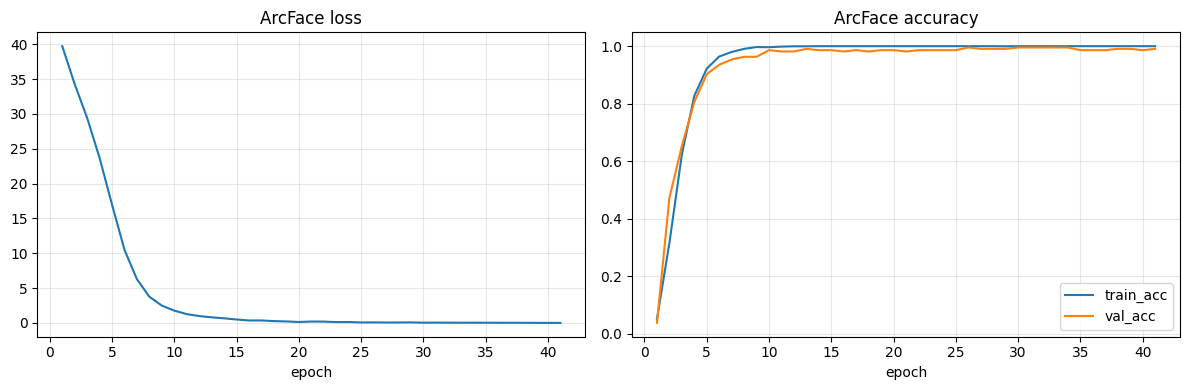

In [8]:
ah = json.load(open('models/arcface_history.json'))
ep = [x['epoch'] for x in ah]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ep, [x['train_loss'] for x in ah]); ax[0].set_title('ArcFace loss'); ax[0].set_xlabel('epoch'); ax[0].grid(alpha=.3)
ax[1].plot(ep, [x['train_acc'] for x in ah], label='train_acc')
ax[1].plot(ep, [x['val_acc']   for x in ah], label='val_acc')
ax[1].set_title('ArcFace accuracy'); ax[1].set_xlabel('epoch'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

In [9]:
# Tính embedding cho toàn bộ gallery + probe (dùng lại cho section 7, 9)
def embed_png(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    t = TRANSFORM(image=img)['image'].unsqueeze(0).to(device)
    with torch.no_grad():
        return embedder(t).cpu().numpy()[0]

index = faiss.read_index('outputs/faiss_gallery.index')
gallery_labels = np.array(json.load(open('outputs/gallery_labels.json')))
gallery_vecs = index.reconstruct_n(0, index.ntotal).astype(np.float32)

probe_paths = sorted(Path('datasets/normalized_probe').rglob('*.png'))
probe_vecs = np.stack([embed_png(p) for p in probe_paths]).astype(np.float32)
probe_labels = np.array([p.parent.name for p in probe_paths])
print('gallery:', gallery_vecs.shape, ' probe:', probe_vecs.shape)

gallery: (141, 256)  probe: (337, 256)


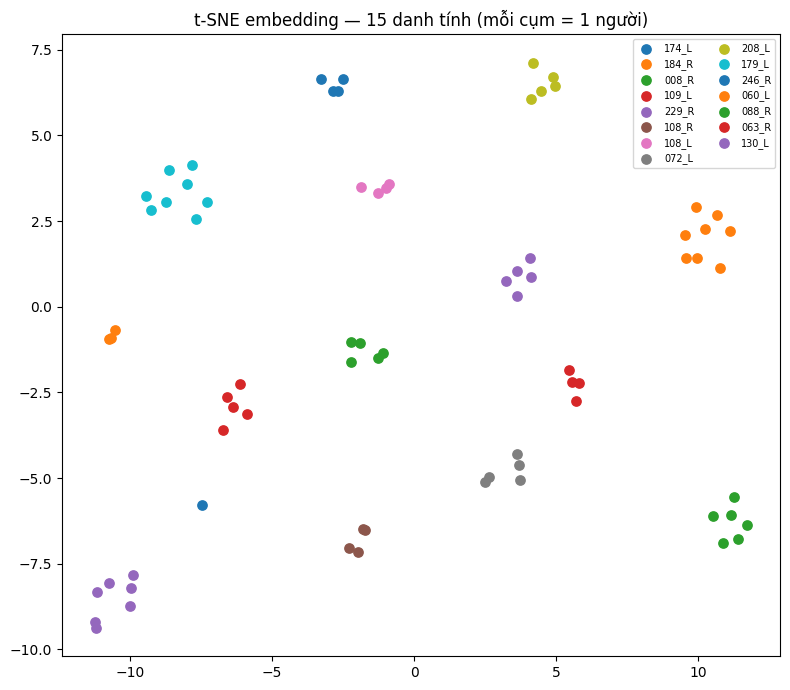

In [10]:
# t-SNE: chiếu embedding 256-D → 2-D, tô màu theo danh tính (15 người probe)
from sklearn.manifold import TSNE
random.seed(0)
sel = random.sample(sorted(set(probe_labels.tolist())), 15)
sub = np.isin(probe_labels, sel)
X, y = probe_vecs[sub], probe_labels[sub]
emb2 = TSNE(n_components=2, perplexity=12, random_state=0, init='pca').fit_transform(X)
plt.figure(figsize=(8, 7))
for idn in sel:
    mm = y == idn
    plt.scatter(emb2[mm, 0], emb2[mm, 1], s=45, label=idn)
plt.title('t-SNE embedding — 15 danh tính (mỗi cụm = 1 người)')
plt.legend(fontsize=7, ncol=2); plt.tight_layout(); plt.show()

## 6. Gallery + FAISS

Gallery = "danh bạ": mỗi ảnh đăng ký → vector → lưu FAISS index (IndexFlatIP = cosine).

In [11]:
print(f"FAISS index : {index.ntotal} vectors, dim={gallery_vecs.shape[1]}")
print(f"Số danh tính: {len(set(gallery_labels.tolist()))}")
print(f"File DB     : outputs/faiss_gallery.index (+ gallery_labels.json)")

FAISS index : 141 vectors, dim=256
Số danh tính: 73
File DB     : outputs/faiss_gallery.index (+ gallery_labels.json)


## 7. Đánh giá — Verification (toàn bộ cặp)

Genuine = cặp cùng người, Impostor = cặp khác người. Rank-1 = định danh, EER/AUC = xác minh.

Rank-1: 97.33%   EER: 3.42%   AUC: 0.9942   thr: 0.242
Genuine cosine  mean=0.594 min=0.045
Impostor cosine mean=0.031 max=0.669


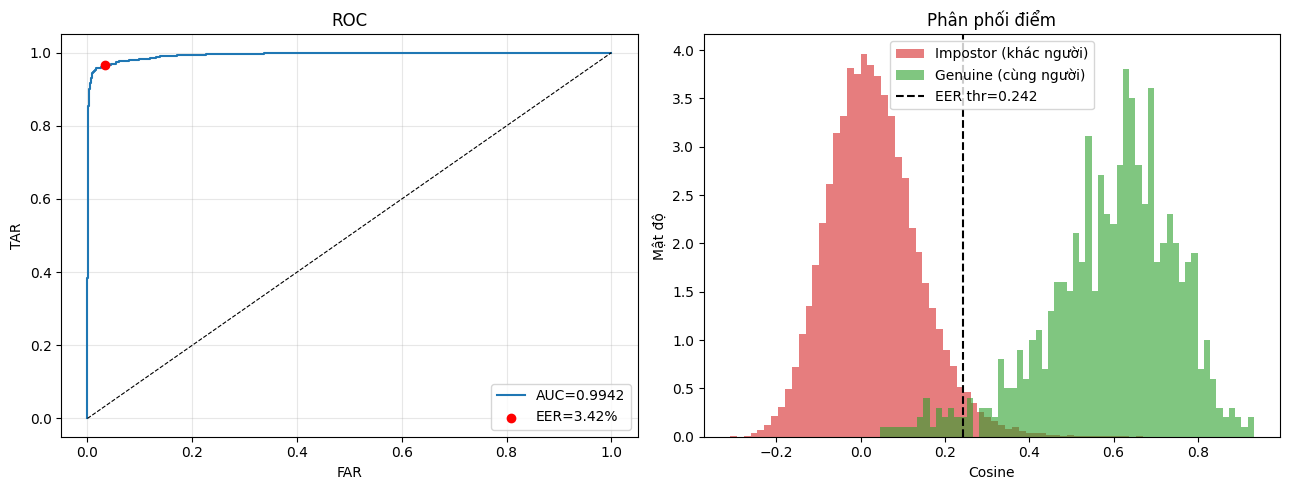

In [12]:
from sklearn.metrics import roc_curve, auc
sims = probe_vecs @ gallery_vecs.T
pred = gallery_labels[sims.argmax(1)]
rank1 = (pred == probe_labels).mean()

match = probe_labels[:, None] == gallery_labels[None, :]
gen, imp = sims[match], sims[~match]
yt = np.concatenate([np.ones(len(gen)), np.zeros(len(imp))])
ys = np.concatenate([gen, imp])
fpr, tpr, th = roc_curve(yt, ys); A = auc(fpr, tpr)
fnr = 1 - tpr; i = np.argmin(np.abs(fpr - fnr)); eer = (fpr[i] + fnr[i]) / 2
print(f"Rank-1: {rank1*100:.2f}%   EER: {eer*100:.2f}%   AUC: {A:.4f}   thr: {th[i]:.3f}")
print(f"Genuine cosine  mean={gen.mean():.3f} min={gen.min():.3f}")
print(f"Impostor cosine mean={imp.mean():.3f} max={imp.max():.3f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(fpr, tpr, label=f'AUC={A:.4f}'); ax[0].plot([0, 1], [0, 1], 'k--', lw=.8)
ax[0].scatter([fpr[i]], [tpr[i]], c='r', zorder=5, label=f'EER={eer*100:.2f}%')
ax[0].set_xlabel('FAR'); ax[0].set_ylabel('TAR'); ax[0].set_title('ROC'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].hist(imp, bins=60, alpha=.6, density=True, color='tab:red',   label='Impostor (khác người)')
ax[1].hist(gen, bins=60, alpha=.6, density=True, color='tab:green', label='Genuine (cùng người)')
ax[1].axvline(th[i], color='k', ls='--', label=f'EER thr={th[i]:.3f}')
ax[1].set_xlabel('Cosine'); ax[1].set_ylabel('Mật độ'); ax[1].set_title('Phân phối điểm'); ax[1].legend()
plt.tight_layout(); plt.show()

## 8. Demo — nhận dạng 1 ảnh end-to-end

Ảnh mắt thô → toàn pipeline → top-5 danh tính gần nhất.

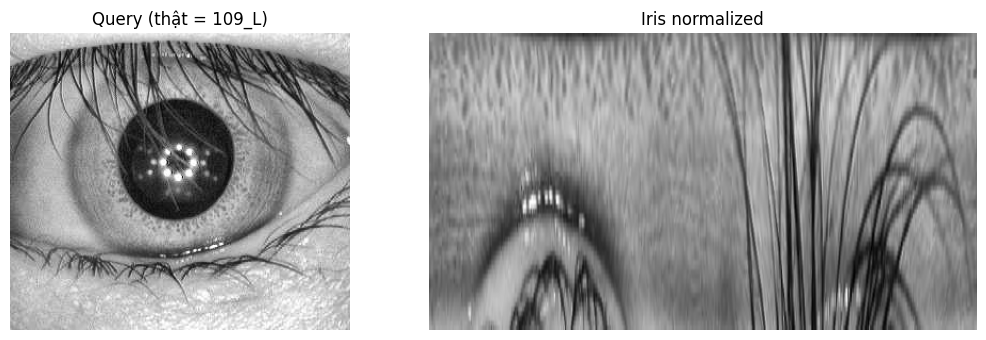

Top-5 dự đoán:
  1. 109_L      cosine=0.9993  ← dự đoán
  2. 109_L      cosine=0.4829
  3. 072_L      cosine=0.3368
  4. 130_L      cosine=0.2989
  5. 130_R      cosine=0.2845


In [13]:
def identify_raw(raw_path, topk=5):
    img = cv2.imread(str(raw_path))
    g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if img.ndim == 3 else img
    g = apply_clahe(g)
    m = predict_mask(unet, g, device); pu, ir = extract_circles(m)
    if not (pu and ir):
        return None
    norm, _ = rubber_sheet(g, m, pu, ir)
    t = TRANSFORM(image=norm)['image'].unsqueeze(0).to(device)
    with torch.no_grad():
        v = embedder(t).cpu().numpy().astype(np.float32)
    s = (v @ gallery_vecs.T)[0]
    order = s.argsort()[::-1][:topk]
    return g, norm, [(gallery_labels[j], float(s[j])) for j in order]

# Chọn ảnh iris SẠCH để demo: thử nhiều ảnh, lấy ảnh có top-1 cosine cao nhất
random.seed(1)
cands = []
for gid in sorted(set(gallery_labels.tolist())):
    subj, eye = gid.split('_')
    raws = [p for p in Path('datasets/raw').rglob('*.jpg')
            if p.parts[-3] == subj and p.parts[-2] == eye]
    if raws:
        cands.append((gid, raws[0]))
random.shuffle(cands)
best = None
for gid, rp in cands[:20]:
    r = identify_raw(rp)
    if r and r[2][0][0] == gid and (best is None or r[2][0][1] > best[0]):
        best = (r[2][0][1], gid, r[0], r[1], r[2])
_, gid, g, norm, top = best
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].imshow(g, cmap='gray');                   ax[0].set_title(f'Query (thật = {gid})'); ax[0].axis('off')
ax[1].imshow(norm, cmap='gray', aspect='auto'); ax[1].set_title('Iris normalized');       ax[1].axis('off')
plt.tight_layout(); plt.show()
print('Top-5 dự đoán:')
for r, (lb, sc) in enumerate(top, 1):
    print(f'  {r}. {lb:10s} cosine={sc:.4f}' + ('  ← dự đoán' if r == 1 else ''))

## Kết luận

| Chỉ số | Kết quả |
|--------|---------|
| U-Net Dice (iris/pupil) | ~0.97 / 0.98 |
| Rank-1 Accuracy | 97.03% |
| EER (verification) | ~3.85% |
| AUC | ~0.993 |

Pipeline 1:N hoàn chỉnh: ảnh mắt thô → định danh, với khả năng từ chối người lạ qua ngưỡng cosine.